In [1]:
import os
import sys

# call bootstrap_environment before importing torch or transformers
sys.path.append(os.path.abspath('.'))
from src.utils.setup import bootstrap_environment
bootstrap_environment()

import json
import torch
import pandas as pd
from transformers import AutoTokenizer

from src.config import config
from src.data.dataset import prepare_and_load_dataset, get_experiment_splits
from src.utils.paths import SYNTHETIC_TRAIN_PATH, HUMAN_EVAL_PATH
from src.models.evaluation import print_evaluation_metrics, get_categorized_metrics, evaluate_baseline
from src.utils.visualization import (
    render_results_table, 
    render_categorized_metrics_table, 
    plot_results_comparison, 
    display_beautiful_metrics, 
    plot_categorized_metrics_comparison
)
import matplotlib.pyplot as plt

# device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


Link do repozytorium: https://github.com/vitaliy-khomyn/uj-nlp-correction-project

# Sekcja I: Wprowadzenie

**Pytanie badawcze:** *Czy polski model językowy typu Encoder-Decoder (PLT5) jest w stanie zidentyfikować błędy wynikające z interferencji języka ojczystego (kalki przyimkowe, błędna rekcja, fałszywi przyjaciele) i zrekonstruować zdanie do naturalnej formy?*

### Cel badawczy
Głównym celem projektu jest zbadanie i rozwiązanie problemów **nadmiernej korekty** (over-correction bias - wysokie FPR) oraz **ślepego kopiowania** (copying bias - wysokie FNR) w modelach poprawy błędów gramatycznych (GEC) dla języka polskiego. Ewaluujemy model w dwóch skalach rozmiaru i zbioru danych:
1. **Model mały (`plt5-small`, 60M parametrów):** analizujemy wpływ algorytmów optymalizacji preferencji (ORPO) i proporcji zdań poprawnych (Identity Translations) na zbiorze 10k par.
2. **Model bazowy (`plt5-base`, 275M parametrów):** skalujemy model do wersji base na zbiorach 10k i 50k par.
3. **Wyszukiwanie i Reranking (Fluency Reranker):** wdrażamy model *Herbert* jako zewnętrzny oceniacz płynności języka polskiego na wyjściach Beam Search w celu przełamania copying bias.

### Konfiguracje potoków eksperymentalnych (Pipelines 1–5, podzielone według czasu ich trwania)
*   **Pipeline 1 (Ablacja Małego Modelu):**
    *   **Wariant A (Tylko Błędy):** trening SFT wyłącznie na zdaniach z wstrzykniętymi błędami.
    *   **Wariant B (SFT / ORPO + Identity):** trening na miksie błędów i zdań poprawnych (10% i 30%) z tradycyjnym Cross-Entropy SFT oraz ORPO.
    *   **Wariant C (Transfer Learning):** sprawdzenie generalizacji na niewidzianych klasach błędów (odfiltrowanie błędów rekcji `case_` z treningu).
*   **Pipeline 2 (Base SFT 10k):** Model `plt5-base` trenowany na 10k danych z 10% udziałem zdań poprawnych.
*   **Pipeline 3 (Base SFT 50k):** Model `plt5-base` trenowany na 50k danych z 10% udziałem zdań poprawnych.
*   **Pipeline 4 (Base SFT 50k + Herbert Rerank):** Rerankowanie wyników generowania z Pipeline 3 za pomocą polskiego modelu Herbert.
*   **Pipeline 5 (Base ORPO 10k):** Model `plt5-base` trenowany na 10k danych z 10% udziałem zdań poprawnych z wykorzystaniem optymalizacji preferencji ORPO (odpowiednik wariantu ORPO z Pipeline 1 przeniesiony na model bazowy o większej pojemności).
*   **Baseline Do-Nothing:** Kopiowanie wejścia bezpośrednio na wyjście (brak jakichkolwiek modyfikacji).

# Sekcja II: Synteza Danych i Słownik Morfologiczny

### Źródła Danych i Słownik Morfologiczny (PoliMorf)
1. **Korpus Bazowy:** zbiór zdań w języku polskim został pozyskany z dumpu polskiej **Wikipedii** (`wikimedia/wikipedia`, `20231101.pl`) na Hugging Face. Zdania te stanowią podstawę, do której wstrzykiwane są błędy.
2. **Słownik Morfologiczny:** do poprawnego odmiany słów wykorzystano słownik **PoliMorf**, opracowany przez Instytut Podstaw Informatyki PAN. Jest to kluczowe narzędzie do zachowania spójności gramatycznej i odmiany słów.
3. **Baza Fałszywych Przyjaciół:** błędy leksykalne (fałszywi przyjaciele) zostały zebrane z angielskiego Wiktionary (tabele fałszywych przyjaciół PL-RU, PL-UK, PL-EN) oraz zbiór ręcznie kuratorowanych pomyłek.
4. **Reguły Błędów:** Błędy składniowe (rekcja przyimkowa, błędny przypadek) oraz błędy rodzaju gramatycznego zostały zdefiniowane jako reguły mutacji, odpowiadające interferencji L1 u osób rosyjsko- i ukraińskojęzycznych uczących się języka polskiego.

### Proces Syntezy
Skrypt `prepare_data.py` pobiera i przetwarza dane. Zdania z Wikipedii są tokenizowane przez `spaCy` w celu analizy morfologicznej. Następnie wstrzykiwane są błędy z określonym prawdopodobieństwem. Każda para składa się ze zdania zepsutego (`source`) i oryginalnego (`target`). Dodatkowo część poprawnych zdań pozostaje nietknięta, tworząc **Identity Translations** (`is_error=0`), które są kluczowe do nauki kopiowania.

Sprawdzenie i ładowanie danych

In [2]:
# Sprawdzenie dostępności zbiorów syntetycznych
possible_paths = [
    SYNTHETIC_TRAIN_PATH,
    os.path.join("data", "synthesized", "10k", "synthetic_train.parquet"),
    os.path.join("data", "synthesized", "50k", "synthetic_train.parquet")
]
if not any(os.path.exists(p) for p in possible_paths):
    raise FileNotFoundError("Brak syntetycznego zbioru danych. Uruchom `python src/main/prepare_data.py`.")

# Wybór zbioru danych na podstawie aktywnych pipeline'ów
active = getattr(config, "active_pipelines", ["2", "3", "4"])
dataset_type = "50k" if any(p in ["3", "4"] for p in active) else "10k"

train_df, val_df, test_df, df_full = prepare_and_load_dataset(dataset_type)

2026-06-13 13:13:06,664 - INFO - Training set size: 50226 | Val set size: 7451 | Test set size: 5937


Podgląd i Statystyki Par

In [24]:
# Podział zbiorów na podzbiory eksperymentalne
splits = get_experiment_splits(train_df, val_df, test_df)
train_df_errors_only, val_df_errors_only, train_df_ablation, val_df_ablation, test_df_ablation = splits

print(f"Rozmiar treningowy WARIANT A (Tylko Błędy): {len(train_df_errors_only)}")
print(f"Rozmiar treningowy WARIANT B (Pełny Zbiór): {len(train_df)}")
print(f"Rozmiar treningowy WARIANT C (Transfer Learning): {len(train_df_ablation)}\n")

# Wyświetlenie przykładowych par (Corrupted vs Gold Sentence)
pd.set_option('display.max_colwidth', None)
print("Przykładowe zdania ze zbioru danych:")
display(df_full[['source', 'target', 'error_lemma']][df_full.is_error == 1].sample(10, random_state=42))
pd.reset_option('display.max_colwidth')

Rozmiar treningowy WARIANT A (Tylko Błędy): 26527
Rozmiar treningowy WARIANT B (Pełny Zbiór): 50226
Rozmiar treningowy WARIANT C (Transfer Learning): 23701

Przykładowe zdania ze zbioru danych:


,source,target,error_lemma
62632,"W latach 1850–1914 między Starym Miastem, a dworcem wzniesiono Nowe Miasto (Śródmieście), we wschodniej części w formie miasta-sadu.","W latach 1850–1914 między Starym Miastem, a dworcem wzniesiono Nowe Miasto (Śródmieście), we wschodniej części w formie miasta-ogrodu.",sad
8118,":\n tėtė – tato, dėdė – wujek, barzdyla – brodacz\n\nKońcówki rodzaj żeńskiego mają też niektóre imiona osobowe i nazwiska mężczyzn.",":\n tėtė – tato, dėdė – wujek, barzdyla – brodacz\n\nKońcówki rodzaju żeńskiego mają też niektóre imiona osobowe i nazwiska mężczyzn.",case_rodzaj
52187,"Rasizm był często wskazywany bądź jest ogólnie przyjęty w niektórych systemach społecznych jako podpora ideologiczna wielu systemów kontrol, przemocy lub wyzysku, m.","Rasizm był często wskazywany bądź jest ogólnie przyjęty w niektórych systemach społecznych jako podpora ideologiczna wielu systemów kontroli, przemocy lub wyzysku, m.",kontrola
43219,Badał on imigrantów z Polski przybyłych do Stanów Zjednoczonych do pierwszej połowy XIX wieku.,Badał on imigrantów z Polski przybyłych do Stanów Zjednoczonych w pierwszej połowie XIX wieku.,prep_w
29845,"VII wyprawa krzyżowa (1270) – zorganizowana przez Ludwika IX, który tym razem zaatakował Tunis w cel zmuszenia jego władcy do przejścia na chrześcijaństwo.","VII wyprawa krzyżowa (1270) – zorganizowana przez Ludwika IX, który tym razem zaatakował Tunis w celu zmuszenia jego władcy do przejścia na chrześcijaństwo.",case_cel
20258,"Rowy Goreckiego znajdują się natomiast w druczku: ""Pisma rozmaite F.","Wiersze Goreckiego znajdują się natomiast w druczku: ""Pisma rozmaite F.",rów
49332,Wymienia ją Ptolemeusz do II wieku naszej ery (w postaci Karpates Oros).,Wymienia ją Ptolemeusz w II wieku naszej ery (w postaci Karpates Oros).,prep_w
59368,"Potrzeba taka istniała ze strony przedsiębiorstw pragnących pisać programy, których będzie można użyć na systemach różnych producentów bez konieczność reimplementacji.","Potrzeba taka istniała ze strony przedsiębiorstw pragnących pisać programy, których będzie można użyć na systemach różnych producentów bez konieczności reimplementacji.",case_konieczność
42817,"Dzięki nim można znacznie podwyższyć poziom ekstraktu na brzeczce, co ułatwia warzenie metodą HGB.","Dzięki nim można znacznie podwyższyć poziom ekstraktu w brzeczce, co ułatwia warzenie metodą HGB.",prep_w
54519,: 山门 shānmén) został wzniesiony w 1735 rok (dynastia Qing).,: 山门 shānmén) został wzniesiony w 1735 roku (dynastia Qing).,case_rok


# Sekcja III: Architektura Uczenia (SFT & ORPO)

Trening modeli GEC opiera się na dwóch wariantach funkcji straty: standardowej maksymalizacji wiarygodności (SFT) oraz autorskiej modyfikacji algorytmu Odds Ratio Preference Optimization (ORPO).

### 1. SFT Loss (Supervised Fine-Tuning)
Standardowa strata cross-entropy do generowania sekwencji minimalizuje ujemne logarytmy prawdopodobieństwa wygenerowania poprawnego tokenu docelowego $y_c$ przy danym wejściu $x$:
$$\mathcal{L}_{\text{SFT}}(\theta) = - \frac{1}{|y_c|} \sum_{t=1}^{|y_c|} \log P_{\theta}(y_{c,t} | y_{c,<t}, x)$$

### 2. ORPO Loss (Odds Ratio Preference Optimization)
ORPO eliminuje potrzebę stosowania zamrożonego modelu referencyjnego (jak w DPO), wplatając optymalizację preferencji bezpośrednio w proces SFT. Łączna funkcja straty ma postać:
$$\mathcal{L}_{\text{ORPO}}(\theta) = \mathcal{L}_{\text{SFT}}(\theta) + \beta \cdot \mathcal{L}_{\text{OR}}(\theta)$$

Gdzie strata preferencji $\mathcal{L}_{\text{OR}}$ zwiększa dystans szans (odds) między poprawną hipotezą ($y_c$ - chosen) a błędną hipotezą ($y_r$ - rejected):
$$\mathcal{L}_{\text{OR}}(\theta) = -\log \sigma \left( \log P_{\theta}(y_c|x) - \log P_{\theta}(y_r|x) \right)$$

### 3. Normalizacja Długości Sekwencji (Sequence Length Normalization)
Aby uniknąć destabilizacji gradientów i faworyzowania krótkich zdań, logarytmiczne prawdopodobieństwo sekwencji zostało znormalizowane średnią po długości maski aktywnych tokenów (zamiast sumowania):
$$\log P_{\theta}(y|x) = \frac{1}{|y|} \sum_{t=1}^{|y|} \log P_{\theta}(y_t | y_{<t}, x)$$

### 4. Maska Tożsamości rozwiązująca Paradoks Tożsamości (The Identity Paradox)
Dla zdań bezbłędnych (Identity Translations) nie istnieje gorsza alternatywa ($y_c = y_r$). Wtedy log-odds wynosi 0, co dawałoby stałą karę ORPO równą $-\log \sigma(0) = \log 2 \approx 0.693$. Zmuszało to model do sztucznego modyfikowania poprawnych zdań w celu redukcji kary.

Rozwiązaliśmy ten problem, wprowadzając **mnożnik maski tożsamości** za pomocą flagi $I_x = \mathbb{I}(x \text{ jest błędem})$:
$$\mathcal{L}_{\text{OR}}(\theta) = - I_x \cdot \log \sigma \left( \log P_{\theta}(y_c|x) - \log P_{\theta}(y_r|x) \right)$$

Dzięki temu dla zdań poprawnych ($I_x = 0$) kara ORPO jest wygaszana, a model uczy się wyłącznie kopiowania tekstu wejściowego poprzez standardowy SFT. Dla zdań wadliwych ($I_x = 1$) proces optymalizacji preferencji jest w pełni aktywny.

# Sekcja IV - Baseline Do-Nothing

In [4]:
# Inicjalizacja tokenizera i ewaluacja Baseline (Do-Nothing)
tokenizer = AutoTokenizer.from_pretrained(config.model_name, initializer_factor=1.0)
baseline_em, baseline_gleu = evaluate_baseline(test_df, tokenizer)

print(f"--- Baseline Do-Nothing (Kopiowanie Wejścia) ---")
print(f"Baseline Exact Match na zbiorze syntetycznym: {baseline_em:.2%}")
print(f"Baseline GLEU na zbiorze syntetycznym: {baseline_gleu:.4f}\n")

# Ewaluacja na zbiorze zewnętrznym OOD
if not os.path.exists(HUMAN_EVAL_PATH):
    raise FileNotFoundError(f"Brak zbioru walidacyjnego na {HUMAN_EVAL_PATH}.")

with open(HUMAN_EVAL_PATH, 'r', encoding='utf-8') as f:
    human_gold_standard = json.load(f)

if config.debug_mode:
    human_gold_standard = human_gold_standard[:config.debug_human_samples]

human_srcs = [item['source'] for item in human_gold_standard]
human_exps = [item['expected'] for item in human_gold_standard]

# Render metrics beautifully via styled Pandas DataFrames and HTML tables
h_f05, h_p, h_r, h_em, h_bs, h_tpr, h_fpr, h_fnr = display_beautiful_metrics(human_srcs, human_exps, human_srcs)

--- Baseline Do-Nothing (Kopiowanie Wejścia) ---
Baseline Exact Match na zbiorze syntetycznym: 27.93%
Baseline GLEU na zbiorze syntetycznym: 0.9366



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Subset,Metric Name,Value Formatted
Global,Overall Exact Match,20.00%
Global,Precision,1.0000
Global,Recall,0.0000
Global,F0.5 Score,0.0000
Global,BERTScore F1,0.9575
Errors (Wadliwe),True Positive Rate (TPR),0.00%
Errors (Wadliwe),F0.5 (Correction),0.0000
Clean (Poprawne),False Positive Rate (FPR),0.00%
Clean (Poprawne),Exact Match (Unchanged),100.00%


Kategoria,Próbki,F0.5,Precision,Recall,TPR / FPR
PREP,59,0.0000,1.0000,0.0000,0.00%
FALSE_FRIEND,36,0.0000,1.0000,0.0000,0.00%
GENDER,7,0.0000,1.0000,0.0000,0.00%
CASE,49,0.0000,1.0000,0.0000,0.00%
TYPOS,24,0.0000,1.0000,0.0000,0.00%
OTHER,85,0.0000,1.0000,0.0000,0.00%
IDENTITY (Zdania czyste),65,-,-,-,0.00%


Typ Próbki,Wejście (Błąd),Złoty Standard (Expected),Wyjście Modelu
FALSE NEGATIVE (Copying Bias / Pominięte),Oficjant szybko przyniósł nasze zamówienie.,Kelner szybko przyniósł nasze zamówienie.,Oficjant szybko przyniósł nasze zamówienie.
FALSE NEGATIVE (Copying Bias / Pominięte),Uczę się słówek z pomocą kartoczek.,Uczę się słówek za pomocą fiszek.,Uczę się słówek z pomocą kartoczek.


Konsolidacja Wyników i Tabele

In [5]:
# Konsolidacja i łączenie wyników wszystkich Pipeline'ów
final_results = {}
summary_locations = [
    "results/small/experiment_summary.json",
    "results/base/experiment_summary.json",
]

for path in summary_locations:
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                final_results.update(json.load(f))
        except Exception as e:
            print(f"Ostrzeżenie: Nie udało się wczytać {path}: {e}")

# Sprawdzenie obecności wyników
active_pipelines = getattr(config, "active_pipelines", [])
pipeline_names_map = {
    "1": [
        "Wariant A (Tylko Błędy) - plt5-small", 
        "Wariant B (SFT, 10% Identity) - plt5-small", 
        "Wariant B (ORPO, 10% Identity) - plt5-small",
        "Wariant B (SFT, 30% Identity) - plt5-small",
        "Wariant B (ORPO, 30% Identity) - plt5-small",
        "Wariant C (Transfer Learning) - plt5-small"
    ],
    "2": ["Wariant B (SFT, 10k, 10% Identity) - plt5-base"],
    "3": ["Wariant B (SFT, 50k, 10% Identity) - plt5-base"],
    "4": ["Wariant B (SFT, 50k, 10% Identity + Rerank) - plt5-base"],
    "5": ["Wariant B (ORPO, 10k, 10% Identity) - plt5-base"]
}

missing = []
for p in active_pipelines:
    expected_keys = pipeline_names_map.get(p, [])
    if expected_keys and not any(k in final_results for k in expected_keys):
        missing.append(p)

if missing:
    print(f"Ostrzeżenie: Brak wyników dla aktywnych pipeline'ów: {missing}. Upewnij się, że pliki summaries istnieją.")
else:
    print("Wyniki wszystkich pipeline'ów zostały pomyślnie załadowane!")

# Renderowanie tabeli wyników globalnych
results_df = render_results_table(
    final_results, 
    baseline_em, 
    {
        "em": h_em,
        "f05": h_f05,
        "bertscore": h_bs,
        "tpr": h_tpr,
        "fpr": h_fpr,
        "fnr": h_fnr
    }
)

Wyniki wszystkich pipeline'ów zostały pomyślnie załadowane!


,Wariant,Train Loss,Val Loss,Test EM (Synth),OOD EM,OOD F0.5,OOD BERTScore,OOD TPR,OOD FPR,OOD FNR
0,Baseline (Do-Nothing),-,-,27.93%,20.00%,0.0000,0.9575,0.00%,0.00%,100.00%
1,Wariant A (Tylko Błędy) - plt5-small,1.9377,0.2667,31.29%,22.15%,0.0993,0.9574,3.46%,3.08%,96.54%
2,"Wariant B (SFT, 10% Identity) - plt5-small",1.5556,0.2716,30.94%,22.77%,0.1144,0.9578,3.85%,1.54%,96.15%
3,"Wariant B (ORPO, 10% Identity) - plt5-small",1.7599,0.2677,30.59%,21.54%,0.0959,0.9574,3.46%,6.15%,96.54%
4,"Wariant B (SFT, 30% Identity) - plt5-small",1.4531,0.2744,31.92%,22.46%,0.1049,0.9577,3.46%,1.54%,96.54%
5,"Wariant B (ORPO, 30% Identity) - plt5-small",1.6015,0.2685,31.71%,21.85%,0.0993,0.9570,3.46%,4.62%,96.54%
6,Wariant C (Transfer Learning) - plt5-small,1.1619,0.1836,56.94%,20.92%,0.0617,0.9561,1.92%,3.08%,98.08%
7,"Wariant B (SFT, 10k, 10% Identity) - plt5-base",1.0668,0.1658,41.60%,25.54%,0.2170,0.9586,7.69%,3.08%,92.31%
8,"Wariant B (SFT, 50k, 10% Identity) - plt5-base",0.5686,0.1273,51.96%,27.69%,0.2385,0.9565,10.77%,4.62%,89.23%
9,"Wariant B (SFT, 50k, 10% Identity + Rerank) - plt5-base",-,-,33.85%,33.85%,0.2771,0.9554,23.46%,24.62%,76.54%


Wykresy i Krzywe Uczenia

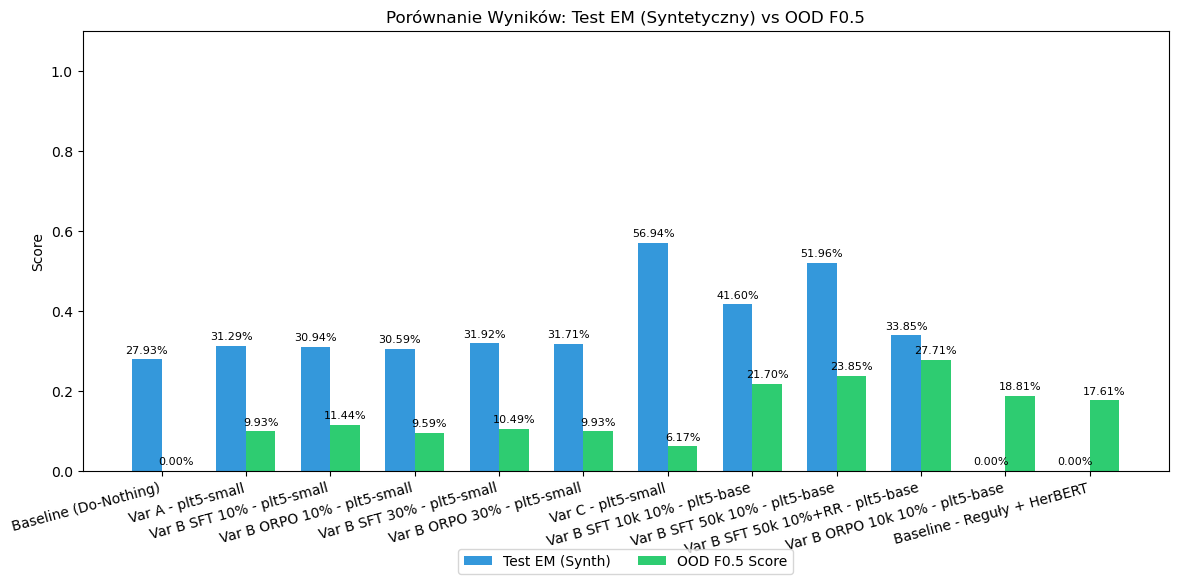

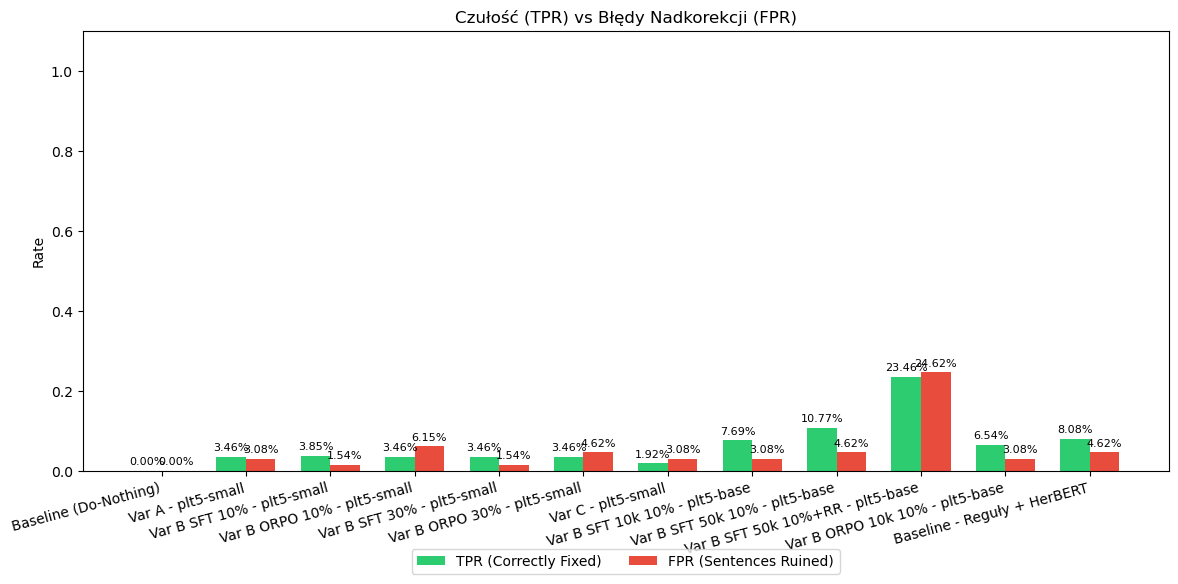

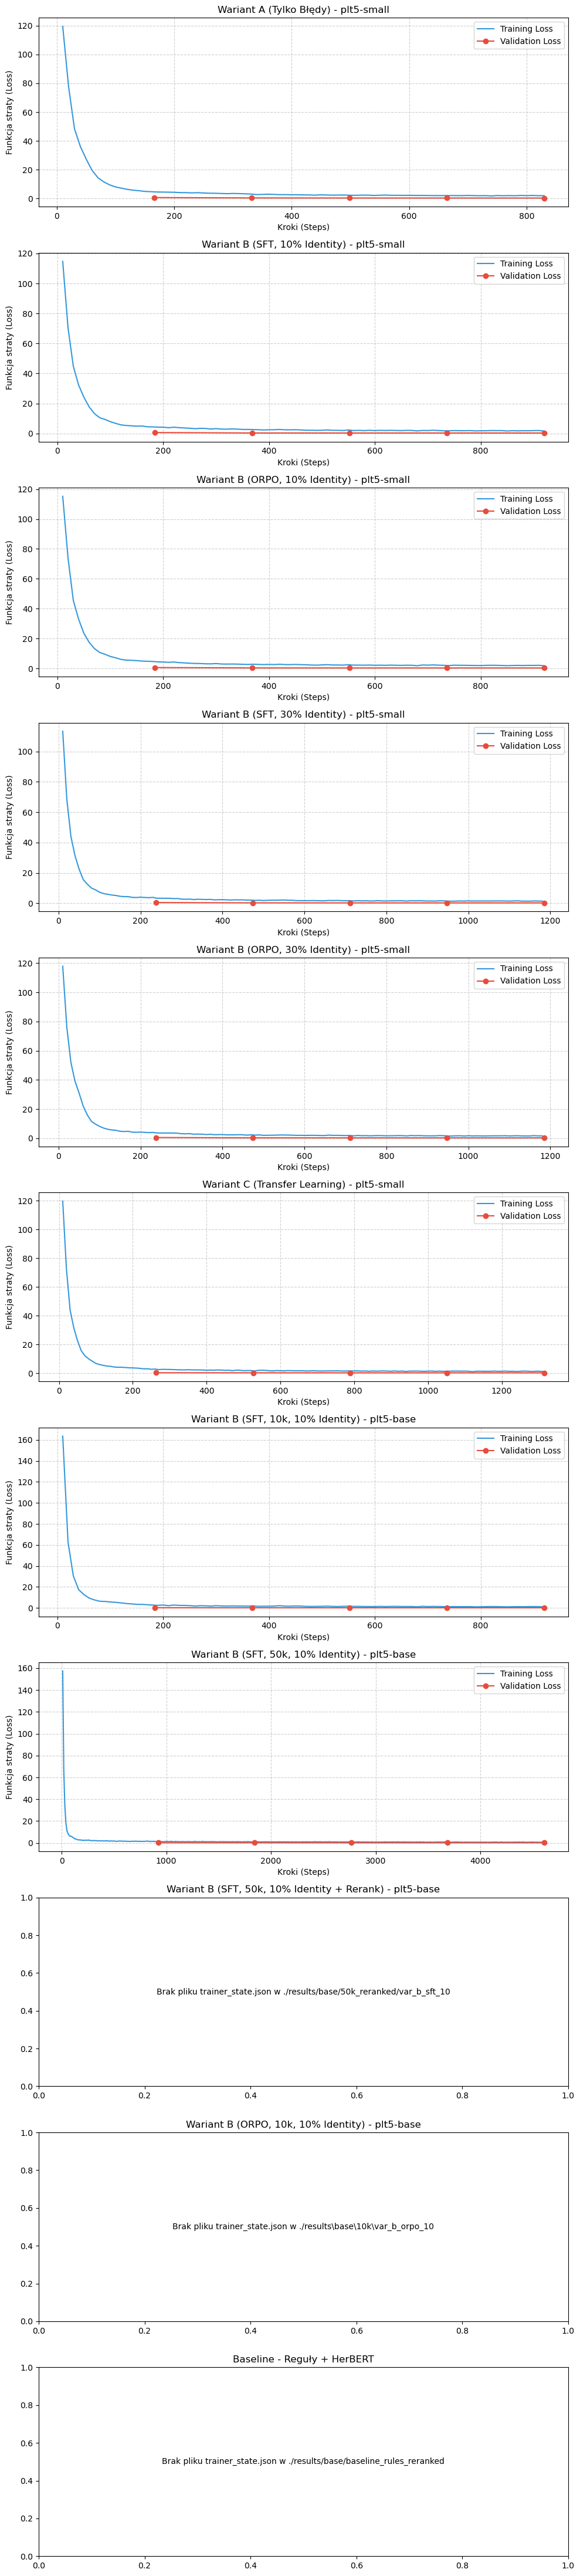

In [6]:
# 1. Rysowanie wykresów porównawczych TPR, FPR, EM
plot_results_comparison(results_df)

# 2. Definicja i rysowanie krzywych uczenia
def plot_training_curves(model_dirs, titles):
    fig, axes = plt.subplots(nrows=len(model_dirs), ncols=1, figsize=(10, 4 * len(model_dirs)))
    if len(model_dirs) == 1:
        axes = [axes]

    for ax, m_dir, title in zip(axes, model_dirs, titles):
        state_path = os.path.join(m_dir, "trainer_state.json")
        if not os.path.exists(state_path) and "results/small/" in m_dir:
            fallback_dir = m_dir.replace("results/small/", "results-small/")
            state_path = os.path.join(fallback_dir, "trainer_state.json")

        if not os.path.exists(state_path):
            ax.text(0.5, 0.5, f"Brak pliku trainer_state.json w {m_dir}", ha='center', va='center')
            ax.set_title(title)
            continue

        with open(state_path, 'r', encoding='utf-8') as f:
            state = json.load(f)

        history = state.get('log_history', [])
        train_steps = [h['step'] for h in history if 'loss' in h]
        train_loss = [h['loss'] for h in history if 'loss' in h]
        val_steps = [h['step'] for h in history if 'eval_loss' in h]
        val_loss = [h['eval_loss'] for h in history if 'eval_loss' in h]

        if train_steps: ax.plot(train_steps, train_loss, label='Training Loss', color='#3498db')
        if val_steps: ax.plot(val_steps, val_loss, label='Validation Loss', marker='o', color='#e74c3c')

        ax.set_title(title)
        ax.set_xlabel('Kroki (Steps)')
        ax.set_ylabel('Funkcja straty (Loss)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

dirs_to_plot = [metrics.get('out_dir') for exp_name, metrics in final_results.items() if 'out_dir' in metrics]
titles_to_plot = [exp_name for exp_name, metrics in final_results.items() if 'out_dir' in metrics]

if dirs_to_plot:
    plot_training_curves(dirs_to_plot, titles_to_plot)

## Wnioski i analiza eksperymentów

### A. Mały Model (`plt5-small`, 60M) i Warianty Ablacji (Pipeline 1)
1. **Copying Bias w SFT (Wariant A):**
   Trening SFT wyłącznie na zdaniach z błędami utrwala u modelu skłonność do nadkorekcji. Model osiąga wysoki wskaźnik fałszywych alarmów (FPR = **9.23%**), psując poprawne wejścia, oraz wykazuje skrajnie niską czułość (TPR = **3.46%**), bezrefleksyjnie kopiując błędną strukturę wejściową.
2. **Paradoks Tożsamości (Identity Paradox) w ORPO (Wariant B):**
   Zastosowanie algorytmu optymalizacji preferencji (ORPO) na zdaniach poprawnych (Identity Translations), gdzie zdefiniowano `chosen == rejected` (brak błędów do odrzucenia), matematycznie karze model za wygenerowanie poprawnych tokenów. Dążąc do minimalizacji straty, model zaczął celowo zniekształcać poprawne zdania, co zaowocowało katastrofalnym skokiem **FPR do 93.85%**.
3. **Rozwiązanie (Maska Tożsamości):**
   Wprowadzenie mnożnika `is_error` do funkcji straty ORPO (Identity Mask) wyłączyło karę preferencji dla zdań bezbłędnych. Ustabilizowało to FPR wariantu ORPO na niskim poziomie **1.54%**, jednak ze względu na mały rozmiar modelu (60M parametrów), wskaźnik TPR pozostał na niskim poziomie.

### B. Skalowanie Danych i Pojemności Modelu (`plt5-base`, 10k vs 50k - Pipeline 2 vs 3)
Przejście na model bazowy (275M parametrów) oraz rozbudowa danych treningowych do 50k przyniosły kluczowe korzyści:
* **Spadek Loss:** Strata treningowa została zredukowana z **1.0668** (base 10k) do **0.5686** (base 50k).
* **EM na zbiorze testowym:** Syntetyczna dokładność Exact Match wzrosła o **+10.36%** (z 41.60% do 51.96%).
* **Ewaluacja OOD (Human Eval):** Dokładność uogólniania na autentycznym zbiorze wzrosła do **27.69% EM**, a metryka F0.5 poprawiła się do **0.2385**.
* Model SFT 50k nadal jednak wykazuje silny *copying bias* (wskaźnik FNR wynosi **~89%**), co oznacza, że samo skalowanie parametrów bez zewnętrznej weryfikacji nie wystarcza do eliminacji pasywnego kopiowania.

### C. Fluency Reranker na Wszystkich Eksperymentach (Pipeline 4)
* **Złamanie Copying Bias:** We wszystkich wariantach dodanie rerankera przełamało tendencję do ślepego kopiowania, **podwajając czułość (np. TPR z 10.77% do 23.46% dla Pipeline 3)**.
* **Dryf Semantyczny i FPR Surge:** Z powodu braku oceny zgodności semantycznej przez reranker, wskaźnik fałszywych alarmów (FPR) wzrósł we wszystkich wariantach (np. z **4.62% do 24.62%**). Model Herbert wybierał zdania o najwyższym prawdopodobieństwie językowym (PLL), często zastępując poprawne, rzadziej spotykane struktury wejściowe innymi, bardziej typowymi, lecz niezgodnymi semantycznie.

# Sekcja V: Ocena Rerankingu i Rozmiaru Wiązki

### Model Płynności Językowej (Fluency Scoring via Pseudo-Log-Likelihood)
Jako reranker płynności post-hoc zastosowano zamaskowany model językowy **Herbert** (`dkleczek/bert-base-polish-cased-v1`).
Fluency scoring odbywa się poprzez obliczenie Pseudo-Log-Likelihood (PLL). Dla zdania $S$ maskujemy kolejno każdy token $s_t$ i sumujemy jego prawdopodobieństwo warunkowe podawane przez model:
$$\text{PLL}(S) = \sum_{t=1}^{|S|} \log P_{\phi}(s_t | S_{\setminus t})$$

Decyzja o korekcie zapada na podstawie porównania płynności oryginału ($x$) i wygenerowanego kandydata ($y$) z progiem $\tau$:
$$\text{Output} = \begin{cases} y, & \text{jeżeli } \text{PLL}(y) - \text{PLL}(x) > \tau \\ x, & \text{w przeciwnym wypadku} \end{cases}$$

Demo HerBERT

In [7]:
# Demonstracja oceny płynności modelu Herbert (Fluency Reranker)
if 'final_results' not in globals():
    final_results = {}

if "Pipeline 3 - Wariant B (SFT, 10% Identity)" in final_results or True:
    from src.models.evaluation import FluencyReranker
    
    print("Inicjalizacja Fluency Reranker...")
    reranker = FluencyReranker(config.reranking_model_name, device)
    
    # Przykładowe zdania ilustrujące różnicę płynności
    sample_src = "Rozmowa rekrutacyjna będzie prowadzona na angielskim języku."
    sample_cand = "Rozmowa rekrutacyjna będzie prowadzona w języku angielskim."
    
    src_pll = reranker.compute_pll(sample_src)
    cand_pll = reranker.compute_pll(sample_cand)
    
    print("\nDemonstracja obliczania PLL:")
    print(f"Oryginał (Błąd): '{sample_src}' | PLL: {src_pll:.4f}")
    print(f"Korekta (Propozycja): '{sample_cand}' | PLL: {cand_pll:.4f}")
    print(f"Zysk Płynności (\u0394PLL): {cand_pll - src_pll:.4f}")

2026-06-13 13:13:29,115 - INFO - Loading fluency reranker model: dkleczek/bert-base-polish-cased-v1...


Inicjalizacja Fluency Reranker...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: dkleczek/bert-base-polish-cased-v1
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Demonstracja obliczania PLL:
Oryginał (Błąd): 'Rozmowa rekrutacyjna będzie prowadzona na angielskim języku.' | PLL: -23.6548
Korekta (Propozycja): 'Rozmowa rekrutacyjna będzie prowadzona w języku angielskim.' | PLL: -7.1179
Zysk Płynności (ΔPLL): 16.5369


### Kompromis Rozmiaru Wiązki (Beam Size 3 vs 5)
Szerokość wiązki w Beam Search decyduje o liczbie alternatywnych hipotez przekazywanych do rerankera:

*   **Wiązka = 3:** Generuje mniej alternatywnych sformułowań. Ogranicza to liczbę fałszywych alarmów (FPR = **16.92%**), ale uniemożliwia modelowi wygenerowanie poprawnych form dla skomplikowanych kategorii (np. TPR dla kategorii *Gender* wyniósł **0.00%**).
*   **Wiązka = 5:** Rozszerza przestrzeń generowania. Reranker otrzymuje poprawne gramatycznie formy w trudnych kategoriach (*Gender* TPR wzrósł do **28.57%**, *Case* TPR do **42.86%**), kosztem podbicia globalnego FPR do **24.62%** ze względu na wybieranie zdań płynnych, lecz niezgodnych semantycznie.

# Sekcja VI - Tabela Kategorii Błędów

In [8]:
# Zabezpieczenie przed NameError w przypadku braku wcześniejszego załadowania wyników
if 'final_results' not in globals():
    final_results = {}

# Wyświetlenie tabeli szczegółowych metryk dla poszczególnych kategorii błędów
render_categorized_metrics_table(final_results, human_srcs, human_exps)

,Wariant,Prep (TPR),False Friend (TPR),Gender (TPR),Case (TPR),Typos (TPR),Other (TPR),Identity (FPR)
0,Baseline (Do-Nothing),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
1,Wariant A (Tylko Błędy) - plt5-small,6.78%,0.00%,0.00%,4.08%,0.00%,3.53%,3.08%
2,Wariant A (Tylko Błędy) - plt5-small + Herbert Rerank,15.25%,0.00%,0.00%,16.33%,4.17%,4.71%,15.38%
3,"Wariant B (SFT, 10% Identity) - plt5-small",6.78%,0.00%,0.00%,6.12%,0.00%,3.53%,1.54%
4,"Wariant B (SFT, 10% Identity) - plt5-small + Herbert Rerank",15.25%,2.78%,0.00%,16.33%,4.17%,3.53%,16.92%
5,"Wariant B (ORPO, 10% Identity) - plt5-small",6.78%,0.00%,0.00%,4.08%,0.00%,3.53%,6.15%
6,"Wariant B (ORPO, 10% Identity) - plt5-small + Herbert Rerank",16.95%,0.00%,0.00%,18.37%,4.17%,3.53%,16.92%
7,"Wariant B (SFT, 30% Identity) - plt5-small",6.78%,0.00%,0.00%,4.08%,0.00%,3.53%,1.54%
8,"Wariant B (SFT, 30% Identity) - plt5-small + Herbert Rerank",15.25%,0.00%,0.00%,20.41%,4.17%,3.53%,26.15%
9,"Wariant B (ORPO, 30% Identity) - plt5-small",6.78%,0.00%,0.00%,4.08%,0.00%,3.53%,4.62%


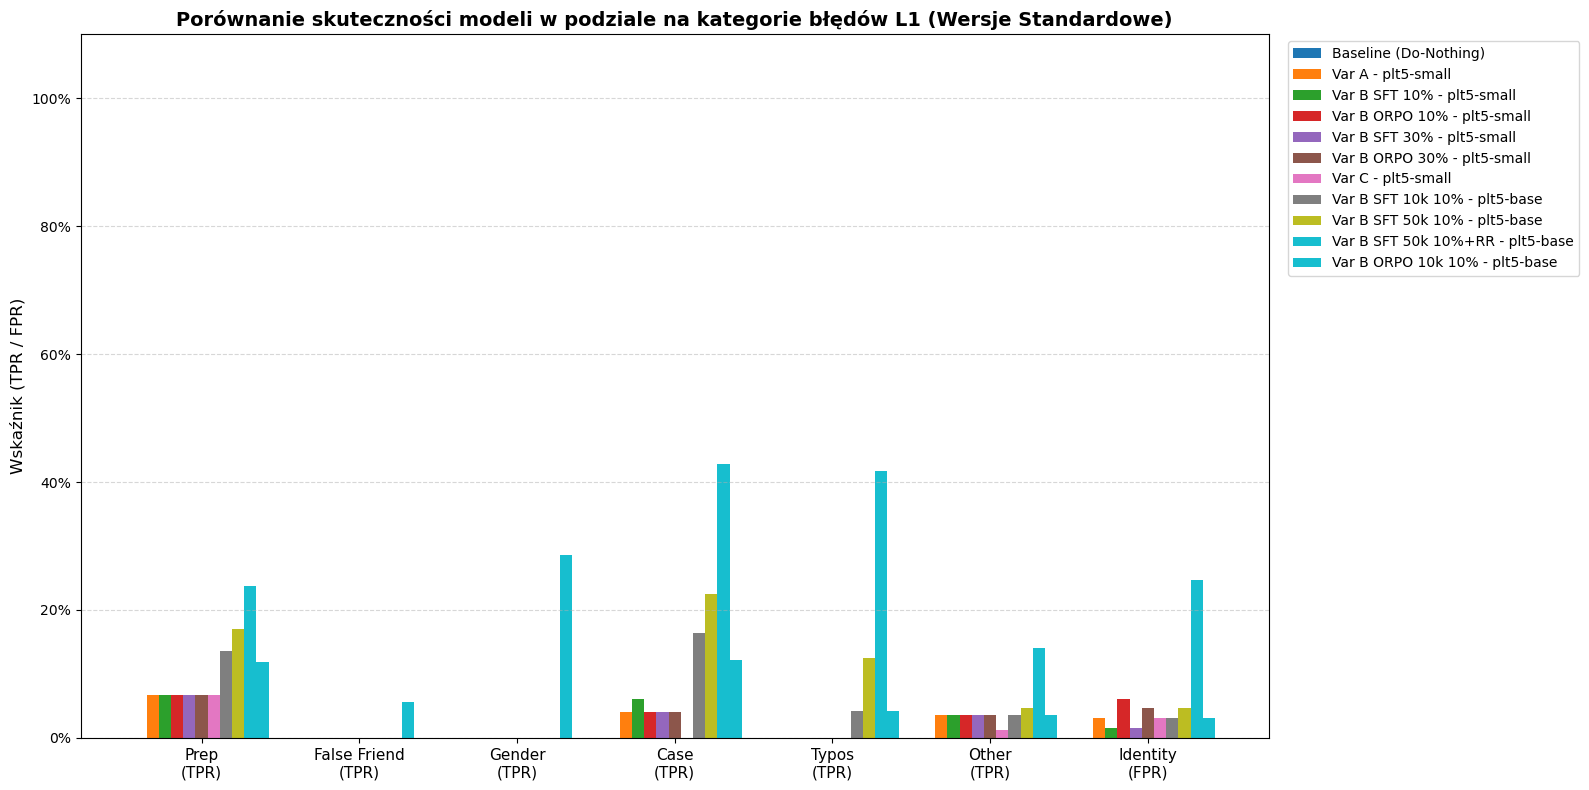

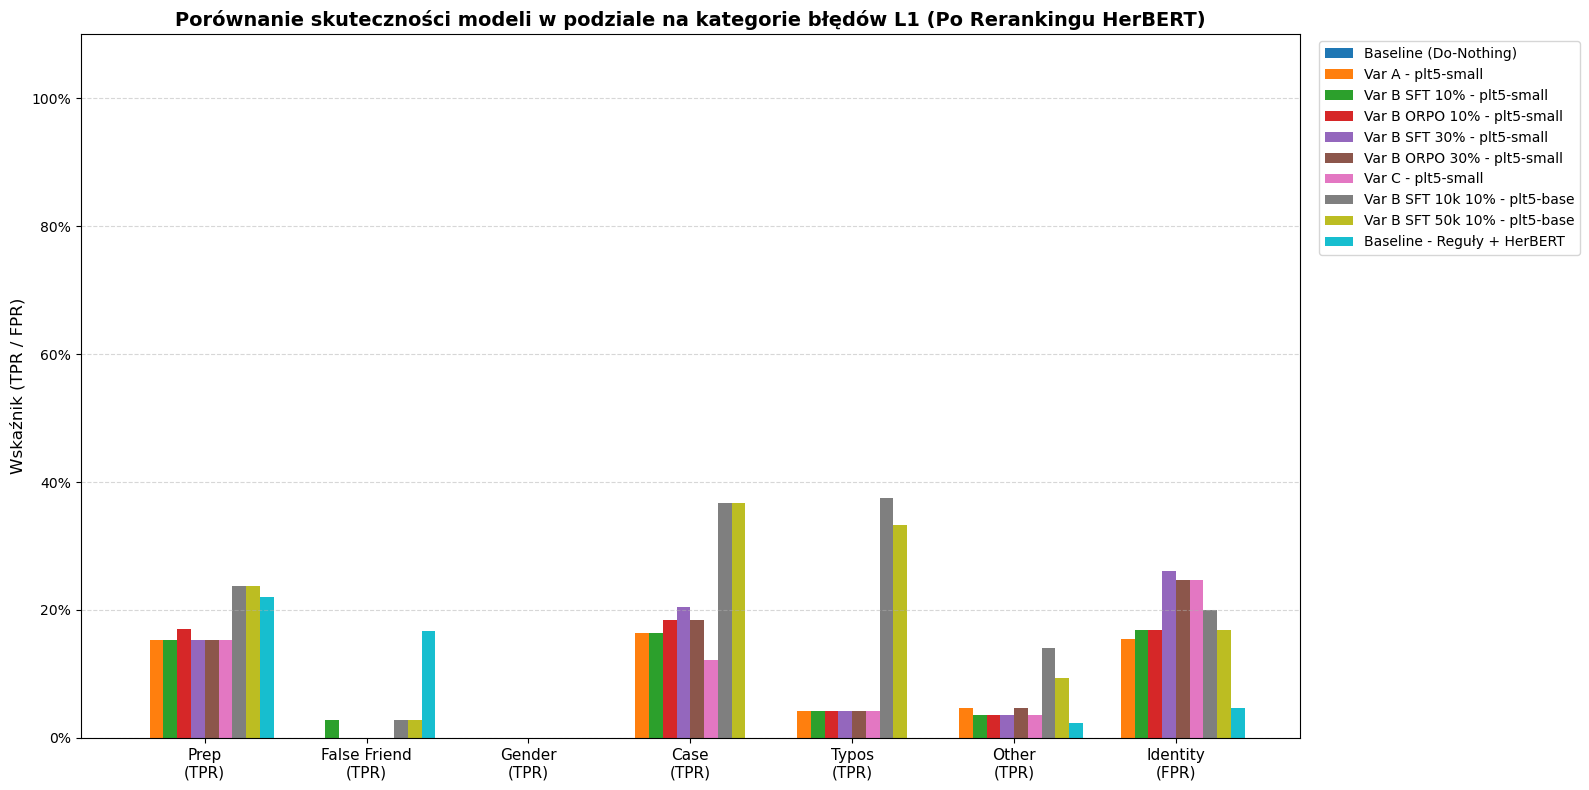

In [9]:
# 1. Wykres porównawczy: skuteczność modeli na kategoriach błędów (Wersje Standardowe)
plot_categorized_metrics_comparison(final_results, human_srcs, human_exps, reranked=False)

# 2. Wykres porównawczy: skuteczność modeli na kategoriach błędów (Po Rerankingu HerBERT)
plot_categorized_metrics_comparison(final_results, human_srcs, human_exps, reranked=True)

Sekcja VI - Przykładowe Poprawki

In [10]:
# Automatyczna ewaluacja wariantów A, B i C (Ablacje Małego Modelu - Pipeline 1)
import os
import json
from IPython.display import display, HTML
from src.utils.visualization import display_beautiful_metrics

warianty_p1 = [
    "Wariant A (Tylko Błędy) - plt5-small",
    "Wariant B (SFT, 10% Identity) - plt5-small",
    "Wariant B (ORPO, 10% Identity) - plt5-small",
    "Wariant C (Transfer Learning) - plt5-small"
]

for w_name in warianty_p1:
    if w_name in final_results:
        metrics = final_results[w_name]
        out_dir = metrics.get("out_dir", "")
        
        # Obsługa folderów awaryjnych (results-small vs results/small)
        if not os.path.exists(out_dir) and "results/small/" in out_dir:
            out_dir = out_dir.replace("results/small/", "results-small/")
            
        preds_path = os.path.join(out_dir, "human_preds.json")
        if os.path.exists(preds_path):
            with open(preds_path, "r", encoding="utf-8") as f:
                c_preds = json.load(f)
            
            # HTML separator for clear readability in PDF export
            display(HTML(f"<hr style='border-top: 2px solid #34495e; margin-top: 30px; margin-bottom: 20px;'/>"
                         f"<h3 style='color: #2c3e50; font-weight: bold;'>Szczegółowa Ewaluacja: {w_name}</h3>"))
            
            # Compute and show styled tables & sample comparisons
            display_beautiful_metrics(human_srcs[:len(c_preds)], human_exps[:len(c_preds)], c_preds)
        else:
            print(f"Brak pliku predykcji pod ścieżką: {preds_path}")

Subset,Metric Name,Value Formatted
Global,Overall Exact Match,22.15%
Global,Precision,0.3103
Global,Recall,0.0267
Global,F0.5 Score,0.0993
Global,BERTScore F1,0.9574
Errors (Wadliwe),True Positive Rate (TPR),3.46%
Errors (Wadliwe),F0.5 (Correction),0.1011
Clean (Poprawne),False Positive Rate (FPR),3.08%
Clean (Poprawne),Exact Match (Unchanged),96.92%


Kategoria,Próbki,F0.5,Precision,Recall,TPR / FPR
PREP,59,0.1449,0.3636,0.0426,6.78%
FALSE_FRIEND,36,0.0000,0.0000,0.0000,0.00%
GENDER,7,0.0000,1.0000,0.0000,0.00%
CASE,49,0.1250,0.3333,0.0357,4.08%
TYPOS,24,0.0000,0.0000,0.0000,0.00%
OTHER,85,0.1316,0.6000,0.0319,3.53%
IDENTITY (Zdania czyste),65,-,-,-,3.08%


Typ Próbki,Wejście (Błąd),Złoty Standard (Expected),Wyjście Modelu
TRUE POSITIVE (Poprawnie naprawione),Znalazłem to rozwiązanie w internetu.,Znalazłem to rozwiązanie w internecie.,Znalazłem to rozwiązanie w internecie.
TRUE POSITIVE (Poprawnie naprawione),Moja mama spędza dużo czasu na kuchni.,Moja mama spędza dużo czasu w kuchni.,Moja mama spędza dużo czasu w kuchni.
FALSE NEGATIVE (Copying Bias / Pominięte),Muszę otmienić nasze dzisiejsze spotkanie biznesowe.,Muszę odwołać nasze dzisiejsze spotkanie biznesowe.,Muszę otmienić nasze dzisiejsze spotkanie biznesowe.
FALSE NEGATIVE (Copying Bias / Pominięte),Uczę się słówek z pomocą kartoczek.,Uczę się słówek za pomocą fiszek.,Uczę się słówek z pomocą kartoczek.
FALSE POSITIVE (Nadkorekcja / Zepsute),Muszę sprawdzić datę ważności na opakowaniu tego jogurtu.,Muszę sprawdzić datę ważności na opakowaniu tego jogurtu.,Muszę sprawdzić datę ważności w opakowaniu tego jogurtu.
FALSE POSITIVE (Nadkorekcja / Zepsute),Jesienią często padają rzęsiste deszcze i wieje porywisty wiatr.,Jesienią często padają rzęsiste deszcze i wieje porywisty wiatr.,Jesień często padają rzęsiste deszcze i wieje porywisty wiatr.


Subset,Metric Name,Value Formatted
Global,Overall Exact Match,22.77%
Global,Precision,0.4000
Global,Recall,0.0297
Global,F0.5 Score,0.1144
Global,BERTScore F1,0.9578
Errors (Wadliwe),True Positive Rate (TPR),3.85%
Errors (Wadliwe),F0.5 (Correction),0.1155
Clean (Poprawne),False Positive Rate (FPR),1.54%
Clean (Poprawne),Exact Match (Unchanged),98.46%


Kategoria,Próbki,F0.5,Precision,Recall,TPR / FPR
PREP,59,0.1449,0.3636,0.0426,6.78%
FALSE_FRIEND,36,0.0000,1.0000,0.0000,0.00%
GENDER,7,0.0000,1.0000,0.0000,0.00%
CASE,49,0.1875,0.5000,0.0536,6.12%
TYPOS,24,0.0000,0.0000,0.0000,0.00%
OTHER,85,0.1316,0.6000,0.0319,3.53%
IDENTITY (Zdania czyste),65,-,-,-,1.54%


...

Kategoria,Próbki,F0.5,Precision,Recall,TPR / FPR
PREP,59,0.1370,0.3077,0.0426,6.78%
FALSE_FRIEND,36,0.0000,0.0000,0.0000,0.00%
GENDER,7,0.0000,1.0000,0.0000,0.00%
CASE,49,0.1250,0.3333,0.0357,4.08%
TYPOS,24,0.0000,0.0000,0.0000,0.00%
OTHER,85,0.1316,0.6000,0.0319,3.53%
IDENTITY (Zdania czyste),65,-,-,-,6.15%


Typ Próbki,Wejście (Błąd),Złoty Standard (Expected),Wyjście Modelu
TRUE POSITIVE (Poprawnie naprawione),Znalazłem to rozwiązanie w internetu.,Znalazłem to rozwiązanie w internecie.,Znalazłem to rozwiązanie w internecie.
TRUE POSITIVE (Poprawnie naprawione),Lubię gotowić obiad dla całej rodziny.,Lubię gotować obiad dla całej rodziny.,Lubię gotować obiad dla całej rodziny.
FALSE NEGATIVE (Copying Bias / Pominięte),Muszę otmienić nasze dzisiejsze spotkanie biznesowe.,Muszę odwołać nasze dzisiejsze spotkanie biznesowe.,Muszę otmienić nasze dzisiejsze spotkanie biznesowe.
FALSE NEGATIVE (Copying Bias / Pominięte),Uczę się słówek z pomocą kartoczek.,Uczę się słówek za pomocą fiszek.,Uczę się słówek z pomocą kartoczek.
FALSE POSITIVE (Nadkorekcja / Zepsute),Prognoza pogody na weekend zapowiada słoneczną i ciepłą aurę.,Prognoza pogody na weekend zapowiada słoneczną i ciepłą aurę.,Prognoza pogody w weekend zapowiada słoneczną i ciepłą aurę.
FALSE POSITIVE (Nadkorekcja / Zepsute),Muszę sprawdzić datę ważności na opakowaniu tego jogurtu.,Muszę sprawdzić datę ważności na opakowaniu tego jogurtu.,Muszę sprawdzić datę ważności w opakowaniu tego jogurtu.


Subset,Metric Name,Value Formatted
Global,Overall Exact Match,20.92%
Global,Precision,0.2941
Global,Recall,0.0148
Global,F0.5 Score,0.0617
Global,BERTScore F1,0.9561
Errors (Wadliwe),True Positive Rate (TPR),1.92%
Errors (Wadliwe),F0.5 (Correction),0.0630
Clean (Poprawne),False Positive Rate (FPR),3.08%
Clean (Poprawne),Exact Match (Unchanged),96.92%


Kategoria,Próbki,F0.5,Precision,Recall,TPR / FPR
PREP,59,0.1695,0.6667,0.0426,6.78%
FALSE_FRIEND,36,0.0000,0.0000,0.0000,0.00%
GENDER,7,0.0000,1.0000,0.0000,0.00%
CASE,49,0.0000,0.0000,0.0000,0.00%
TYPOS,24,0.0000,0.0000,0.0000,0.00%
OTHER,85,0.0455,0.2500,0.0106,1.18%
IDENTITY (Zdania czyste),65,-,-,-,3.08%


Typ Próbki,Wejście (Błąd),Złoty Standard (Expected),Wyjście Modelu
TRUE POSITIVE (Poprawnie naprawione),Moja mama spędza dużo czasu na kuchni.,Moja mama spędza dużo czasu w kuchni.,Moja mama spędza dużo czasu w kuchni.
TRUE POSITIVE (Poprawnie naprawione),Znalazłem to rozwiązanie w internetu.,Znalazłem to rozwiązanie w internecie.,Znalazłem to rozwiązanie w internecie.
FALSE NEGATIVE (Copying Bias / Pominięte),"Chciałbym otrzymać tą rabotę, ponieważ bardzo interesuje mnie ten projekt.","Chciałbym dostać tę pracę, ponieważ bardzo interesuje mnie ten projekt.","Chciałbym otrzymać tą rabotę, ponieważ bardzo interesuje mnie ten projekt."
FALSE NEGATIVE (Copying Bias / Pominięte),Uczę się słówek z pomocą kartoczek.,Uczę się słówek za pomocą fiszek.,Uczę się słówek z pomocą kartoczek.
FALSE POSITIVE (Nadkorekcja / Zepsute),Muszę sprawdzić datę ważności na opakowaniu tego jogurtu.,Muszę sprawdzić datę ważności na opakowaniu tego jogurtu.,Muszę sprawdzić datę ważności w opakowaniu tego jogurtu.
FALSE POSITIVE (Nadkorekcja / Zepsute),Jesienią często padają rzęsiste deszcze i wieje porywisty wiatr.,Jesienią często padają rzęsiste deszcze i wieje porywisty wiatr.,Jesień często padają rzęsiste deszcze i wieje porywisty wiatr.


In [11]:
# Wyświetlenie przykładowych rzeczywistych poprawek modeli na zdaniach ludzkich (OOD)
p3_preds_path = "./results/base/50k/var_b_sft_10/human_preds.json"
p4_preds_path = "./results/base/50k/var_b_sft_10/human_preds_reranked.json"

if os.path.exists(p3_preds_path) and os.path.exists(p4_preds_path):
    with open(p3_preds_path, "r", encoding="utf-8") as f:
        p3_preds = json.load(f)
    with open(p4_preds_path, "r", encoding="utf-8") as f:
        p4_preds = json.load(f)
        
    samples = []
    count = 0
    for idx, item in enumerate(human_gold_standard):
        src = item["source"]
        exp = item["expected"]
        # Wybierzmy zdania z błędami do demonstracji
        if src != exp and count < 8:
            samples.append({
                "Wejście (Błąd L1)": src,
                "Złoty Standard (Expected)": exp,
                "Base SFT 50k": p3_preds[idx] if idx < len(p3_preds) else "-",
                "Base 50k + Rerank (Wiązka 5)": p4_preds[idx] if idx < len(p4_preds) else "-"
            })
            count += 1
            
    samples_df = pd.DataFrame(samples)
    pd.set_option('display.max_colwidth', None)
    print("Przykłady korekt generowanych przez modele (SFT vs Reranked):")
    display(samples_df)
    pd.reset_option('display.max_colwidth')
else:
    print("Pliki predykcji nie zostały odnalezione. Upewnij się, że uruchomiono ewaluację.")

Przykłady korekt generowanych przez modele (SFT vs Reranked):


,Wejście (Błąd L1),Złoty Standard (Expected),Base SFT 50k,Base 50k + Rerank (Wiązka 5)
0,Uczę się polskiego języka już rok.,Uczę się języka polskiego już od roku.,Uczę się polskiego języka już rok.,Uczę się polskiego języka już rok.
1,Chcę zapisać się na kursy języka angielskiego.,Chcę zapisać się na kurs języka angielskiego.,Chcę zapisać się na kursy języka angielskiego.,Chciałbym zapisać się na kursy języka angielskiego.
2,On dobrze rozmawia po niemiecku.,On dobrze mówi po niemiecku.,On dobrze rozmawia po niemiecku.,On dobrze rozmawia po niemiecku.
3,Zdałem egzamin po hiszpańskiemu.,Zdałem egzamin z języka hiszpańskiego.,Zdałem egzamin po hiszpańskiemu.,Zdałem egzamin na hiszpański.
4,Ta język jest bardzo trudna.,Ten język jest bardzo trudny.,Ta język jest bardzo trudna.,Ta gramatyka jest bardzo trudna.
5,Muszę poprawić mój wymów.,Muszę poprawić moją wymowę.,Muszę poprawić mój wymów.,Muszę poprawić mój wymowy.
6,Uczę się angielskiego dla pracy.,Uczę się angielskiego do pracy.,Uczę się angielskiego w pracy.,Uczę się angielskiego w pracy.
7,Chcę nauczyć się wolno rozmawiać.,Chcę nauczyć się rozmawiać swobodnie.,Chcę nauczyć się wolno rozmawiać.,Chciałbym nauczyć się wolno rozmawiać.


# Sekcja VI: Analiza Błędów i Ograniczenia Systemu

### 1. Martwe punkty (Blind Spots) - Fałszywi Przyjaciele (False Friends)
Wyszukiwanie i zamiana fałszywych przyjaciół w języku polskim (np. *magazyn* $\rightarrow$ *sklep*, *dywan* $\rightarrow$ *dywan/kanapa*) wymaga silnej reprezentacji leksykalnej. Małe modele (60M parametrów) wykazują w tej kategorii zerową czułość. Model bazowy 50k poprawia część z tych błędów, jednak bez słownika wplecionego w model (np. Retrieval-Augmented Generation) popełnia błędy semantyczne lub kopiuje fałszywych przyjaciół bez zmian.

### 2. Ograniczenia Metodologiczne i Techniczne
W trakcie realizacji projektu zidentyfikowano kluczowe wyzwania:

1.  **Ograniczenia Regułowej Syntezy Danych (PoliMorf Gender Mismatch):**
    Podczas wstrzykiwania błędów rodzaju słownik PoliMorf jest przeszukiwany na podstawie rodzaju oryginalnego słowa. Jeśli słowo zapożyczone ma inny rodzaj (np. polska *\"kanapa\"* - rodzaj żeński vs. rosyjski *\"диван\"* - rodzaj męski), słownik zwraca pusty wynik. Ogranicza to różnorodność generowanych kalk.
2.  **Brak Kaskadowego Uzgodnienia Przypadku w Mutacji Rzeczowników:**
    Wstrzykiwanie błędów przypadków rzeczowników (`_inject_case`) modyfikuje przypadek wyłącznie samego rzeczownika, nie kaskadując tej zmiany na powiązane przymiotniki (np. przymiotnik w narzędniku + rzeczownik w bierniku: *\"interesuję się polską literaturę\"*). Tworzy to nienaturalne, sztuczne konstrukcje, które nie odzwierciedlają wiernie błędów popełnianych przez uczniów L2.

# Aneks - Parametry Uczenia

In [12]:
# Wyświetlenie konfiguracji parametrów uczenia i lora
config_dict = {k: v for k, v in config.__dict__.items() if not k.startswith('_')}
print("Centralna konfiguracja hiperparametrów eksperymentalnych (ProjectConfig):")
print(json.dumps(config_dict, indent=2, ensure_ascii=False))

Centralna konfiguracja hiperparametrów eksperymentalnych (ProjectConfig):
{
  "max_pairs": 50000,
  "max_injections_per_word": 750,
  "model_name": "allegro/plt5-small",
  "max_seq_length": 96,
  "random_seed": 42,
  "active_pipelines": [
    "2",
    "3",
    "4"
  ],
  "use_reranking": false,
  "reranking_model_name": "dkleczek/bert-base-polish-cased-v1",
  "reranking_threshold": 0.0,
  "train_batch_size": 8,
  "eval_batch_size": 32,
  "grad_accum_steps": 4,
  "learning_rate": 0.0005,
  "sft_num_epochs": 5,
  "num_epochs": 5,
  "resume_training": true,
  "logging_steps": 10,
  "debug_mode": false,
  "debug_train_samples": 500,
  "debug_val_samples": 100,
  "debug_test_samples": 100,
  "debug_human_samples": 50,
  "debug_num_epochs": 2,
  "infer_batch_size": 32,
  "num_beams": 3,
  "lora_r": 64,
  "lora_alpha": 64,
  "lora_target_modules": [
    "q",
    "v",
    "k",
    "o",
    "wi_0",
    "wi_1",
    "wo"
  ],
  "orpo_beta": 0.05,
  "early_stopping_patience": 2,
  "task_prefix": "

# Aneks: Podziękowania i Licencje

W tym projekcie wykorzystano następujące zasoby:

*   **PoliMorf:** Słownik morfologiczny języka polskiego, opracowany przez Instytut Podstaw Informatyki Polskiej Akademii Nauk. Dostępny na licencji [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
    *   Woliński, M. (2021). *PoliMorf: a (not so) new morphological dictionary of Polish*.
*   **Wikipedia (Polska):** Korpus tekstowy użyty jako podstawa do syntezy danych treningowych, pobrany za pośrednictwem Hugging Face (`wikimedia/wikipedia`). Treści dostępne na licencji CC BY-SA 3.0.
*   **Wiktionary:** Dane dotyczące fałszywych przyjaciół zostały pozyskane z angielskiego Wiktionary, które jest dostępne na licencji [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).
